In [1]:
import numpy as np
import pandas as pd
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


## **MNIST** dataset for digit recognition
- shape of one image is 20x28=784 + 1(label). Each pixel is a column in our dataset.

#### **Steps of PAC**
- Mean Centerized data (Standardize the Data): `X - mean`
- Compute the Covariance Matrix : `np.cov(X.T)`
- Compute Eigenvalues and Eigenvectors : `eig(cov)`
- Sort Eignevalues and Eigenvectors : `argsort()`
- Select Top `k` Principal Components : `[:, :k]`
- Transform the Data (Project data onto new axis) : `X.dot(V)`

### <font color="blue">**Step 1:** ***Normal Model Prediction without PCA***</font>

In [3]:
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df.shape

(42000, 785)

In [5]:
df.describe()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
count,42000.000000,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,42000.0,...,42000.000000,42000.000000,42000.000000,42000.00000,42000.000000,42000.000000,42000.0,42000.0,42000.0,42000.0
mean,4.456643,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.219286,0.117095,0.059024,0.02019,0.017238,0.002857,0.0,0.0,0.0,0.0
std,2.887730,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.312890,4.633819,3.274488,1.75987,1.894498,0.414264,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.00000,254.000000,62.000000,0.0,0.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42000 entries, 0 to 41999
Columns: 785 entries, label to pixel783
dtypes: int64(785)
memory usage: 251.5 MB


Label:  8


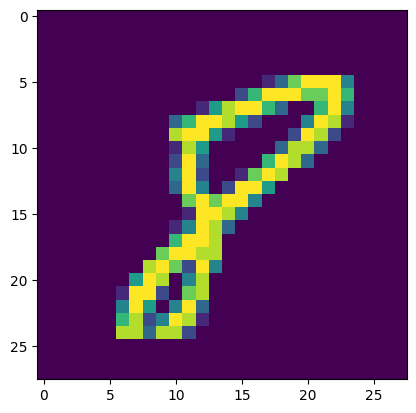

In [7]:
import matplotlib.pyplot as plt
digit_img = df.iloc[18306,1:].values.reshape(28, 28)
print("Label: ", df.iloc[18306, 0]) #label
plt.imshow(digit_img)


Label:  4


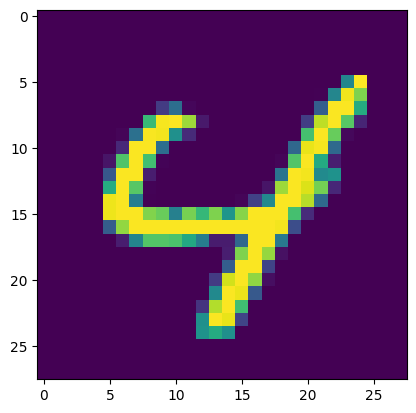

In [8]:
digit_img = df.iloc[18284,1:].values.reshape(28, 28)
print("Label: ", df.iloc[18284, 0]) #label
plt.imshow(digit_img)

Label:  6


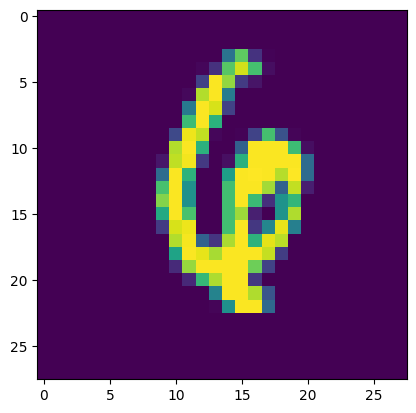

In [9]:
digit_img = df.iloc[15045,1:].values.reshape(28, 28)
print("Label: ", df.iloc[15045, 0]) #label
plt.imshow(digit_img)

In [10]:
# X(features) and y(labels) extract
X = df.iloc[:, 1:] # features
y = df.iloc[:, 0] # label

In [11]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((33600, 784), (33600,), (8400, 784), (8400,))

In [12]:
# Model import
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()

# fit the model
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [13]:
# Predict
import time
start = time.time()
y_pred = knn.predict(X_test)
end = time.time()
print("Execution time: ", end-start)
y_pred.shape

Execution time:  13.497826099395752


(8400,)

In [14]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred) * 100
round(accuracy, 3)

96.488

### <font color="blue">**Step 2:** ***Model Prediction with PCA***</font>
#### **Steps of PAC**
- Mean Centerized data (Standardize the Data): `X - mean`
- Compute the Covariance Matrix : `np.cov(X.T)`
- Compute Eigenvalues and Eigenvectors : `eig(cov)`
- Sort Eignevalues and Eigenvectors : `argsort()`
- Select Top `k` Principal Components : `[:, :k]`
- Transform the Data (Project data onto new axis) : `X.dot(V)`

In [15]:
# X(features) and y(labels) extract
X = df.iloc[:, 1:] # features
y = df.iloc[:, 0] # label

In [16]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((33600, 784), (33600,), (8400, 784), (8400,))

In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Mean centering
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled.shape

(33600, 784)

In [18]:
# PCA
from sklearn.decomposition import PCA
# pca = PCA(n_components=None)
pca = PCA(n_components=100)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

X_train_pca.shape

(33600, 100)

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train_pca, y_train)

KNeighborsClassifier()

In [20]:
import time
start = time.time()
y_predict = knn.predict(X_test_pca)
end = time.time()
print("Execution Time: ", end-start)
y_predict.shape

Execution Time:  1.852595567703247


(8400,)

In [21]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_predict) * 100
round(accuracy, 3)

95.369

### **<font color="green">Check PCA in a Loop</font>**

In [22]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
import time

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]  # Features (pixels)
y = df.iloc[:, 0]   # Labels (digit classes)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a pipeline with StandardScaler, PCA, and KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Add scaling step
    ('pca', PCA()),
    ('knn', KNeighborsClassifier())
])

# Lists to store results for potential plotting
components = []
accuracies = []
times = []

# Loop over different numbers of PCA components
for i in range(1, 785, 50):
    # Set the number of components for PCA in the pipeline
    pipeline.set_params(pca__n_components=i)
    
    start = time.time()
    pipeline.fit(X_train, y_train)
    y_predict = pipeline.predict(X_test)
    end = time.time()
    
    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_predict) * 100
    
    # Store results
    components.append(i)
    accuracies.append(accuracy)
    times.append(end - start)
    
    # Print results
    print(f"PCA components: {i}, Accuracy: {round(accuracy, 3)}%, Execution Time: {round(end - start, 3)} seconds")


PCA components: 1, Accuracy: 25.798%, Execution Time: 1.793 seconds
PCA components: 51, Accuracy: 95.393%, Execution Time: 5.031 seconds
PCA components: 101, Accuracy: 95.417%, Execution Time: 5.253 seconds
PCA components: 151, Accuracy: 95.131%, Execution Time: 6.405 seconds
PCA components: 201, Accuracy: 95.012%, Execution Time: 7.805 seconds
PCA components: 251, Accuracy: 94.821%, Execution Time: 9.886 seconds
PCA components: 301, Accuracy: 94.702%, Execution Time: 10.922 seconds
PCA components: 351, Accuracy: 94.429%, Execution Time: 11.809 seconds
PCA components: 401, Accuracy: 94.369%, Execution Time: 14.241 seconds
PCA components: 451, Accuracy: 94.298%, Execution Time: 15.09 seconds
PCA components: 501, Accuracy: 94.048%, Execution Time: 17.609 seconds
PCA components: 551, Accuracy: 94.048%, Execution Time: 18.067 seconds
PCA components: 601, Accuracy: 93.964%, Execution Time: 20.242 seconds
PCA components: 651, Accuracy: 94.024%, Execution Time: 11.887 seconds
PCA components: 

### ***784D >---PCA--->>> 2D***

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.colors as pc

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA to reduce to 2 dimensions
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Create DataFrame for plotting
pca_df = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'Label': y_train.astype(str)
})

# Plot using Plotly Express
fig = px.scatter(
    pca_df,
    x='PC1',
    y='PC2',
    color='Label',
    color_discrete_sequence=pc.qualitative.G10,
    title='PCA Projection of MNIST (Train Set)',
    opacity=0.7
)

fig.show()


### ***784D >---PCA--->>> 3D***

In [27]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import plotly.express as px
import plotly.colors as pc

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]
y = df.iloc[:, 0]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA with 3 components
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Prepare DataFrame for Plotly 3D plotting
pca_df = pd.DataFrame({
    'PC1': X_train_pca[:, 0],
    'PC2': X_train_pca[:, 1],
    'PC3': X_train_pca[:, 2],
    'Label': y_train.astype(str)
})

# 3D Scatter plot using Plotly
fig = px.scatter_3d(
    pca_df,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Label',
    color_discrete_sequence=pc.qualitative.G10,
    title='3D PCA Projection of MNIST (Train Set)',
    opacity=0.7
)

fig.show()


### ***PCA  Components***

In [2]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]  # Features (pixel values)
y = df.iloc[:, 0]   # Labels (digits)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA on scaled data
pca = PCA(n_components=3)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Print PCA statistics
print("Explained Variance (Eigenvalues):")
print(pca.explained_variance_)

print("\nPrincipal Components (Eigenvectors):")
print(pca.components_)

print("\nShape of PCA Components Matrix:")
print(pca.components_.shape)

print("\nPCA Variance:")
print(pca.explained_variance_ratio_)


Explained Variance (Eigenvalues):
[40.67111197 29.17023395 26.74459602]

Principal Components (Eigenvectors):
[[ 2.99197741e-18  5.00239483e-19  1.82248832e-19 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [-3.49945943e-17 -7.50708503e-17 -1.86393158e-18 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 1.70836061e-16 -8.30062762e-18  1.14701040e-18 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]

Shape of PCA Components Matrix:
(3, 784)

PCA Variance:
[0.05785192 0.0414927  0.03804239]


In [5]:
# find out the optimum number of pca component
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]  # Features (pixel values)
y = df.iloc[:, 0]   # Labels (digits)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA on scaled data
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Print PCA statistics
print("Explained Variance (Eigenvalues):")
print(pca.explained_variance_)

print("Explained Variance Shape (Eigenvalues):")
print(pca.explained_variance_.shape)

print("\nPrincipal Components (Eigenvectors):")
print(pca.components_)

print("\nShape of PCA Components Matrix:")
print(pca.components_.shape)


Explained Variance (Eigenvalues):
[4.06711120e+01 2.91702340e+01 2.67445962e+01 2.08534479e+01
 1.81489188e+01 1.58529825e+01 1.38710810e+01 1.24805897e+01
 1.10279424e+01 1.00958253e+01 9.63317821e+00 8.62785945e+00
 8.06303131e+00 7.89511749e+00 7.44167929e+00 7.17032873e+00
 6.73266373e+00 6.62744023e+00 6.41499161e+00 6.25808269e+00
 5.90495742e+00 5.76521585e+00 5.52084601e+00 5.32003847e+00
 5.18309925e+00 4.93439597e+00 4.90652171e+00 4.71800493e+00
 4.49824444e+00 4.43140305e+00 4.32604521e+00 4.23491831e+00
 4.10335015e+00 4.06731180e+00 4.02362178e+00 3.84130473e+00
 3.81886146e+00 3.71316498e+00 3.60918108e+00 3.47303214e+00
 3.42842989e+00 3.38841159e+00 3.29157511e+00 3.22927379e+00
 3.21745142e+00 3.15810372e+00 3.12620905e+00 3.10412385e+00
 3.05892795e+00 3.03728188e+00 2.96540461e+00 2.94033669e+00
 2.86828564e+00 2.82617865e+00 2.80038441e+00 2.77411221e+00
 2.71978838e+00 2.69394232e+00 2.64724369e+00 2.63065837e+00
 2.56498699e+00 2.53651735e+00 2.48789582e+00 2.446

In [6]:
print("\nPCA Variance:")
print(pca.explained_variance_ratio_)


PCA Variance:
[5.78519225e-02 4.14926968e-02 3.80423901e-02 2.96626277e-02
 2.58156168e-02 2.25498018e-02 1.97306802e-02 1.77527998e-02
 1.56865066e-02 1.43606328e-02 1.37025484e-02 1.22725500e-02
 1.14691200e-02 1.12302739e-02 1.05852885e-02 1.01993106e-02
 9.57676152e-03 9.42708817e-03 9.12489429e-03 8.90170190e-03
 8.39940495e-03 8.20063196e-03 7.85303229e-03 7.56739707e-03
 7.37261022e-03 7.01884653e-03 6.97919728e-03 6.71104483e-03
 6.39845030e-03 6.30337291e-03 6.15350848e-03 6.02388659e-03
 5.83673972e-03 5.78547759e-03 5.72333148e-03 5.46399774e-03
 5.43207369e-03 5.28172755e-03 5.13381744e-03 4.94015474e-03
 4.87671103e-03 4.81978768e-03 4.68204430e-03 4.59342487e-03
 4.57660834e-03 4.49219022e-03 4.44682221e-03 4.41540749e-03
 4.35111936e-03 4.32032928e-03 4.21808870e-03 4.18243127e-03
 4.07994349e-03 4.02004913e-03 3.98335855e-03 3.94598812e-03
 3.86871612e-03 3.83195184e-03 3.76552618e-03 3.74193467e-03
 3.64852155e-03 3.60802540e-03 3.53886455e-03 3.47941353e-03
 3.443234

In [7]:
# Cumulative sum [0 + n] <= 99.9%
np.cumsum(pca.explained_variance_ratio_)

array([0.05785192, 0.09934462, 0.13738701, 0.16704964, 0.19286525,
       0.21541506, 0.23514574, 0.25289854, 0.26858504, 0.28294568,
       0.29664822, 0.30892077, 0.32038989, 0.33162017, 0.34220546,
       0.35240477, 0.36198153, 0.37140862, 0.38053351, 0.38943521,
       0.39783462, 0.40603525, 0.41388828, 0.42145568, 0.42882829,
       0.43584714, 0.44282633, 0.44953738, 0.45593583, 0.4622392 ,
       0.46839271, 0.4744166 , 0.48025334, 0.48603881, 0.49176214,
       0.49722614, 0.50265822, 0.50793994, 0.51307376, 0.51801392,
       0.52289063, 0.52771041, 0.53239246, 0.53698588, 0.54156249,
       0.54605468, 0.5505015 , 0.55491691, 0.55926803, 0.56358836,
       0.56780645, 0.57198888, 0.57606882, 0.58008887, 0.58407223,
       0.58801822, 0.59188694, 0.59571889, 0.59948441, 0.60322635,
       0.60687487, 0.6104829 , 0.61402176, 0.61750117, 0.62094441,
       0.62432378, 0.62767368, 0.63099377, 0.63426257, 0.63746765,
       0.64065542, 0.64376931, 0.64686564, 0.64992395, 0.65296

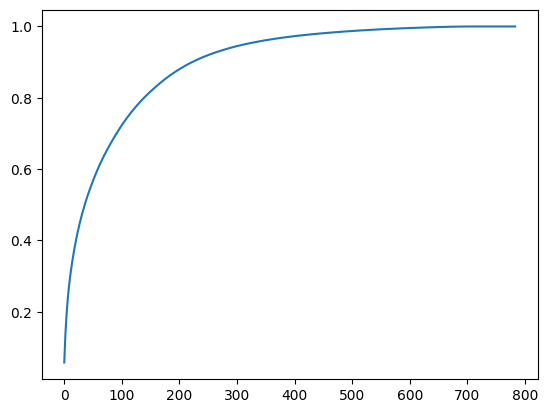

In [9]:
from matplotlib import pyplot as plt
plt.plot(np.cumsum(pca.explained_variance_ratio_))


In [10]:
# After seeing the above graph. You could take n_component = 200 for the PCA.
# find out the optimum number of pca component
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load the dataset
df = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")

# Extract features and labels
X = df.iloc[:, 1:]  # Features (pixel values)
y = df.iloc[:, 0]   # Labels (digits)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardize features (zero mean, unit variance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Perform PCA on scaled data
pca = PCA(n_components=200)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

# Print PCA statistics
print("Explained Variance (Eigenvalues):")
print(pca.explained_variance_)

print("Explained Variance Shape (Eigenvalues):")
print(pca.explained_variance_.shape)

print("\nPrincipal Components (Eigenvectors):")
print(pca.components_)

print("\nShape of PCA Components Matrix:")
print(pca.components_.shape)


Explained Variance (Eigenvalues):
[40.67111198 29.17023401 26.74459621 20.85344792 18.14891878 15.8529825
 13.87108101 12.48058967 11.02794236 10.09582533  9.63317821  8.62785945
  8.06303131  7.89511749  7.44167929  7.17032873  6.73266371  6.62744022
  6.4149916   6.25808268  5.90495741  5.76521584  5.52084598  5.32003845
  5.18309922  4.93439594  4.90652166  4.71800484  4.49824431  4.43140292
  4.32604511  4.23491821  4.10334993  4.06731161  4.0236213   3.84130425
  3.81886128  3.71316465  3.60918006  3.47303153  3.42842864  3.38841044
  3.29157433  3.22927159  3.2174503   3.15810216  3.12620688  3.10412083
  3.05892607  3.03727854  2.96540146  2.94033226  2.86828083  2.8261724
  2.80038105  2.77411     2.71978284  2.69393507  2.64723885  2.63065044
  2.56498341  2.53651153  2.48788926  2.44609173  2.42065659  2.37574205
  2.3550344   2.3340752   2.29801558  2.25320921  2.24104586  2.18910816
  2.17675287  2.15003421  2.13511437  2.11867091  2.09856983  2.08165535
  2.04960621  2.030

## **<font color='red'>When PCA does not Work**</font>
1. __Swiss Roll (Non-Linear 3D Mainfold):__ A 3D dataset that rolls into a spiral, often used to show the limits of PCA.
2. __Two Interleaving Moons:__ Non-linear and not linearly separable — PCA cannot capture the structure.
3. __Concentric Circles:__ Radial symmetry and non-linear structure — not suitable for PCA.
4. __Categorical Data (One-hot encoded):__ PCA assumes numerical continuous data; categorical one-hot encoded data doesn't align well with PCA.
5. __Sparse Binary Data:__ Extremely sparse data (like bag-of-words or transaction data) where PCA gives noisy components.
6. __Specific Pattern:__ If your dataset have specific patter like (y=x^2) then do not apply `PCA`. Because after `PCA` you will loose the pattern.
___Note :___ non-linear dimensionality reduction techniques like `t-SNE`, `UMAP`, and `Kernel PCA` handle the non-linear datasets where traditional `PCA` fails.

In [21]:
# 1. Swiss Roll
import numpy as np
import plotly.express as px
from sklearn.datasets import make_swiss_roll

# Generate Swiss Roll data
X, color = make_swiss_roll(n_samples=1000, noise=0.2)

# Create interactive 3D scatter plot
fig = px.scatter_3d(
    x=X[:, 0],
    y=X[:, 1],
    z=X[:, 2],
    color=color,
    title="Swiss Roll - Non-linear Structure",
    labels={'x': 'X', 'y': 'Y', 'z': 'Z'}
)
fig.show()


In [22]:
# 2. Two Interleaving Moons
import numpy as np
import plotly.express as px
from sklearn.datasets import make_moons

# Generate two moons data
X, y = make_moons(n_samples=500, noise=0.05)

# Create interactive 2D scatter plot
fig = px.scatter(
    x=X[:, 0],
    y=X[:, 1],
    color=y.astype(str),
    title="Two Moons - Non-linear Data",
    labels={'x': 'X1', 'y': 'X2'}
)
fig.show()



In [23]:
# 3. Concentric Circle
import numpy as np
import plotly.express as px
from sklearn.datasets import make_circles

# Generate concentric circles data
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05)

# Create interactive 2D scatter plot
fig = px.scatter(
    x=X[:, 0],
    y=X[:, 1],
    color=y.astype(str),
    title="Concentric Circles - Non-linear Data",
    labels={'x': 'X1', 'y': 'X2'}
)
fig.show()



In [24]:
# 4. Categorical Data
import pandas as pd
import plotly.express as px

# Simulate one-hot encoded data
df = pd.DataFrame({
    'Color_Red':    [1, 0, 0, 1, 0],
    'Color_Blue':   [0, 1, 0, 0, 1],
    'Color_Green':  [0, 0, 1, 0, 0]
})
df.index = ['Sample 1', 'Sample 2', 'Sample 3', 'Sample 4', 'Sample 5']

# Create interactive heatmap
fig = px.imshow(
    df,
    text_auto=True,
    color_continuous_scale='RdBu',
    title="One-hot Encoded Categorical Data"
)
fig.show()


In [25]:
# 5. Sparse Binary Data
import numpy as np
from scipy.sparse import random as sparse_random
import plotly.graph_objects as go

# Generate sparse binary matrix
X_sparse = sparse_random(100, 100, density=0.02, format='csr', random_state=42)
X_dense = X_sparse.toarray()

# Create interactive heatmap to visualize sparsity
fig = go.Figure(data=go.Heatmap(
    z=X_dense,
    colorscale='Greys',
    showscale=False
))
fig.update_layout(
    title="Sparse Binary Data",
    xaxis_title="Feature",
    yaxis_title="Sample"
)
fig.show()



In [26]:
# 6. Sphere (Uniform Points on a Sphere Surface)
import numpy as np
import plotly.express as px

# Generate spherical coordinates
phi = np.linspace(0, np.pi, 40)
theta = np.linspace(0, 2 * np.pi, 40)
phi, theta = np.meshgrid(phi, theta)

x = np.sin(phi) * np.cos(theta)
y = np.sin(phi) * np.sin(theta)
z = np.cos(phi)

# Flatten for plotting
x_flat = x.flatten()
y_flat = y.flatten()
z_flat = z.flatten()

fig = px.scatter_3d(
    x=x_flat,
    y=y_flat,
    z=z_flat,
    title="3D Sphere Surface",
    labels={"x": "X", "y": "Y", "z": "Z"}
)
fig.show()


In [27]:
#  Helix (Spiral along Z-axis)
import numpy as np
import plotly.express as px

# Generate helix
t = np.linspace(0, 8 * np.pi, 1000)
x = np.cos(t)
y = np.sin(t)
z = t

fig = px.scatter_3d(
    x=x, y=y, z=z,
    title="3D Helix (Spiral)",
    labels={"x": "X", "y": "Y", "z": "Z"},
    color=z
)
fig.show()


In [29]:
# Torus (Doughnut-shaped Surface)
import numpy as np
import plotly.express as px

# Torus parameters
R = 3  # major radius
r = 1  # minor radius

theta = np.linspace(0, 2 * np.pi, 40)
phi = np.linspace(0, 2 * np.pi, 40)
theta, phi = np.meshgrid(theta, phi)

x = (R + r * np.cos(theta)) * np.cos(phi)
y = (R + r * np.cos(theta)) * np.sin(phi)
z = r * np.sin(theta)

# Flatten
x_flat = x.flatten()
y_flat = y.flatten()
z_flat = z.flatten()

fig = px.scatter_3d(
    x=x_flat,
    y=y_flat,
    z=z_flat,
    title="3D Torus (Donut)",
    labels={"x": "X", "y": "Y", "z": "Z"}
)
fig.show()


In [30]:
# S-Curve (Similar to Swiss Roll but Different Curve)
from sklearn.datasets import make_s_curve
import plotly.express as px

# Generate S-curve
X, color = make_s_curve(n_samples=1000, noise=0.1)

fig = px.scatter_3d(
    x=X[:, 0],
    y=X[:, 1],
    z=X[:, 2],
    color=color,
    title="3D S-Curve - Nonlinear Structure",
    labels={'x': 'X', 'y': 'Y', 'z': 'Z'}
)
fig.show()


#### **Note :** Non-linear dimensionality reduction techniques like `t-SNE`, `UMAP`, and `Kernel PCA` handle the non-linear datasets where traditional `PCA` fails.

In [18]:
# 1. Swiss Roll - 3D -> 2D
import numpy as np
import plotly.express as px
from sklearn.datasets import make_swiss_roll
from sklearn.manifold import TSNE
import umap
from sklearn.decomposition import KernelPCA

# Generate Swiss Roll
X, color = make_swiss_roll(n_samples=1000, noise=0.2)

# Apply dimensionality reduction
X_tsne = TSNE(n_components=2, init='pca', random_state=0).fit_transform(X)
X_umap = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X)
X_kpca = KernelPCA(n_components=2, kernel='rbf').fit_transform(X)

# Create interactive plots
fig_tsne = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1], color=color, title="t-SNE on Swiss Roll")
fig_umap = px.scatter(x=X_umap[:, 0], y=X_umap[:, 1], color=color, title="UMAP on Swiss Roll")
fig_kpca = px.scatter(x=X_kpca[:, 0], y=X_kpca[:, 1], color=color, title="Kernel PCA (RBF) on Swiss Roll")

# Show plots
fig_tsne.show()
fig_umap.show()
fig_kpca.show()


In [19]:
# Two Moons
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=300, noise=0.05)

X_tsne = TSNE(n_components=2).fit_transform(X)
X_umap = umap.UMAP().fit_transform(X)
X_kpca = KernelPCA(n_components=2, kernel='rbf').fit_transform(X)

# Create interactive plots
fig_tsne = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1], color=y, title="t-SNE on Two Moons")
fig_umap = px.scatter(x=X_umap[:, 0], y=X_umap[:, 1], color=y, title="UMAP on Two Moons")
fig_kpca = px.scatter(x=X_kpca[:, 0], y=X_kpca[:, 1], color=y, title="Kernel PCA (RBF) on Two Moons")

# Show plots
fig_tsne.show()
fig_umap.show()
fig_kpca.show()


In [20]:
# Concentric Circles
from sklearn.datasets import make_circles

X, y = make_circles(n_samples=300, factor=0.5, noise=0.05)

X_tsne = TSNE(n_components=2).fit_transform(X)
X_umap = umap.UMAP().fit_transform(X)
X_kpca = KernelPCA(n_components=2, kernel='rbf').fit_transform(X)

# Create interactive plots
fig_tsne = px.scatter(x=X_tsne[:, 0], y=X_tsne[:, 1], color=y, title="t-SNE on Circles")
fig_umap = px.scatter(x=X_umap[:, 0], y=X_umap[:, 1], color=y, title="UMAP on Circles")
fig_kpca = px.scatter(x=X_kpca[:, 0], y=X_kpca[:, 1], color=y, title="Kernel PCA (RBF) on Circles")

# Show plots
fig_tsne.show()
fig_umap.show()
fig_kpca.show()
